In [9]:
!pip install -q wfdb PyWavelets

import os, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pywt
import wfdb
from collections import Counter

plt.rcParams['figure.dpi'] = 110

In [6]:
import glob, os

# Search recursively from the dataset root for .dat files
candidates = glob.glob('/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/**/*.dat', recursive=True)
print(f"Found {len(candidates)} .dat files")
print(candidates[:5])

DATA_DIR = os.path.dirname(candidates[0])
print("\nUsing DATA_DIR =", DATA_DIR)
print(sorted(os.listdir(DATA_DIR))[:15])

Found 71 .dat files
['/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/103.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/113.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/202.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/217.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/219.dat']

Using DATA_DIR = /kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0
['100.atr', '100.dat', '100.hea', '100.xws', '101.atr', '101.dat', '101.hea', '101.xws', '102-0.atr', '102.atr', '102.dat', '102.hea', '102.xws', '103.atr', '103.dat']


In [7]:
records = sorted(set(os.path.basename(f).replace('.dat','') for f in glob.glob(f'{DATA_DIR}/*.dat')))
print(f"Total records: {len(records)}")
print(records)

Total records: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [10]:
sample_rec = wfdb.rdrecord(os.path.join(DATA_DIR, records[0]))

print("Record name        :", sample_rec.record_name)
print("Sampling frequency  :", sample_rec.fs, "Hz")
print("Signal length       :", sample_rec.sig_len, "samples =", sample_rec.sig_len/sample_rec.fs, "s")
print("Number of leads     :", sample_rec.n_sig)
print("Lead names          :", sample_rec.sig_name)
print("Units               :", sample_rec.units)
print("ADC gain            :", sample_rec.adc_gain)
print("Comments            :", sample_rec.comments)

Record name        : 100
Sampling frequency  : 360 Hz
Signal length       : 650000 samples = 1805.5555555555557 s
Number of leads     : 2
Lead names          : ['MLII', 'V5']
Units               : ['mV', 'mV']
ADC gain            : [200.0, 200.0]
Comments            : ['69 M 1085 1629 x1', 'Aldomet, Inderal']


In [11]:
from collections import Counter

all_symbols = Counter()
for rec_name in records:
    try:
        ann = wfdb.rdann(os.path.join(DATA_DIR, rec_name), 'atr')
        all_symbols.update(ann.symbol)
    except Exception as e:
        print(f"Skipped {rec_name}: {e}")

print("Beat symbol counts across all 48 records:")
for sym, count in all_symbols.most_common(15):
    print(f"  {sym!r:>4}: {count}")

Beat symbol counts across all 48 records:
   'N': 75052
   'L': 8075
   'R': 7259
   'V': 7130
   '/': 7028
   'A': 2546
   '+': 1291
   'f': 982
   'F': 803
   '~': 616
   '!': 472
   '"': 437
   'j': 229
   'x': 193
   'a': 150


In [12]:
def band_power_fraction(x, lo, hi, fs):
    f, p = signal.welch(x, fs=fs, nperseg=2048)
    total = np.trapezoid(p, f)
    m = (f >= lo) & (f <= hi)
    return 100 * np.trapezoid(p[m], f[m]) / total if total > 0 else 0

noise_profile = []
for rec_name in records:
    rec = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    x = rec.p_signal[:, 0]   # MLII lead
    fs = rec.fs
    bw = band_power_fraction(x, 0, 0.5, fs)
    pl = band_power_fraction(x, 59, 61, fs)
    hf = band_power_fraction(x, 100, fs/2, fs)
    noise_profile.append((rec_name, bw, pl, hf))

noise_profile.sort(key=lambda r: -r[1])
print(f"{'Record':<8}{'BaselineWander%':>16}{'Powerline%':>12}{'HighFreq%':>12}")
for r in noise_profile:
    print(f"{r[0]:<8}{r[1]:>16.2f}{r[2]:>12.3f}{r[3]:>12.4f}")

Record   BaselineWander%  Powerline%   HighFreq%
108                39.78       0.088      0.0235
121                28.05       0.002      0.0257
111                22.48       0.180      0.0297
222                21.15       0.288      0.0547
219                18.35       0.002      0.0051
114                17.37       0.459      0.0774
203                14.38       0.057      0.0095
228                14.26       0.056      0.0165
207                13.69       0.058      0.0130
116                13.69       0.004      0.0110
112                12.22       0.007      0.0304
124                12.09       0.001      0.0071
101                10.99       0.081      0.0208
234                10.23       0.003      0.0127
115                 9.64       0.002      0.0182
209                 9.49       0.104      0.0250
105                 8.46       0.033      0.0086
208                 7.56       0.054      0.0076
212                 7.50       0.114      0.0171
210                 

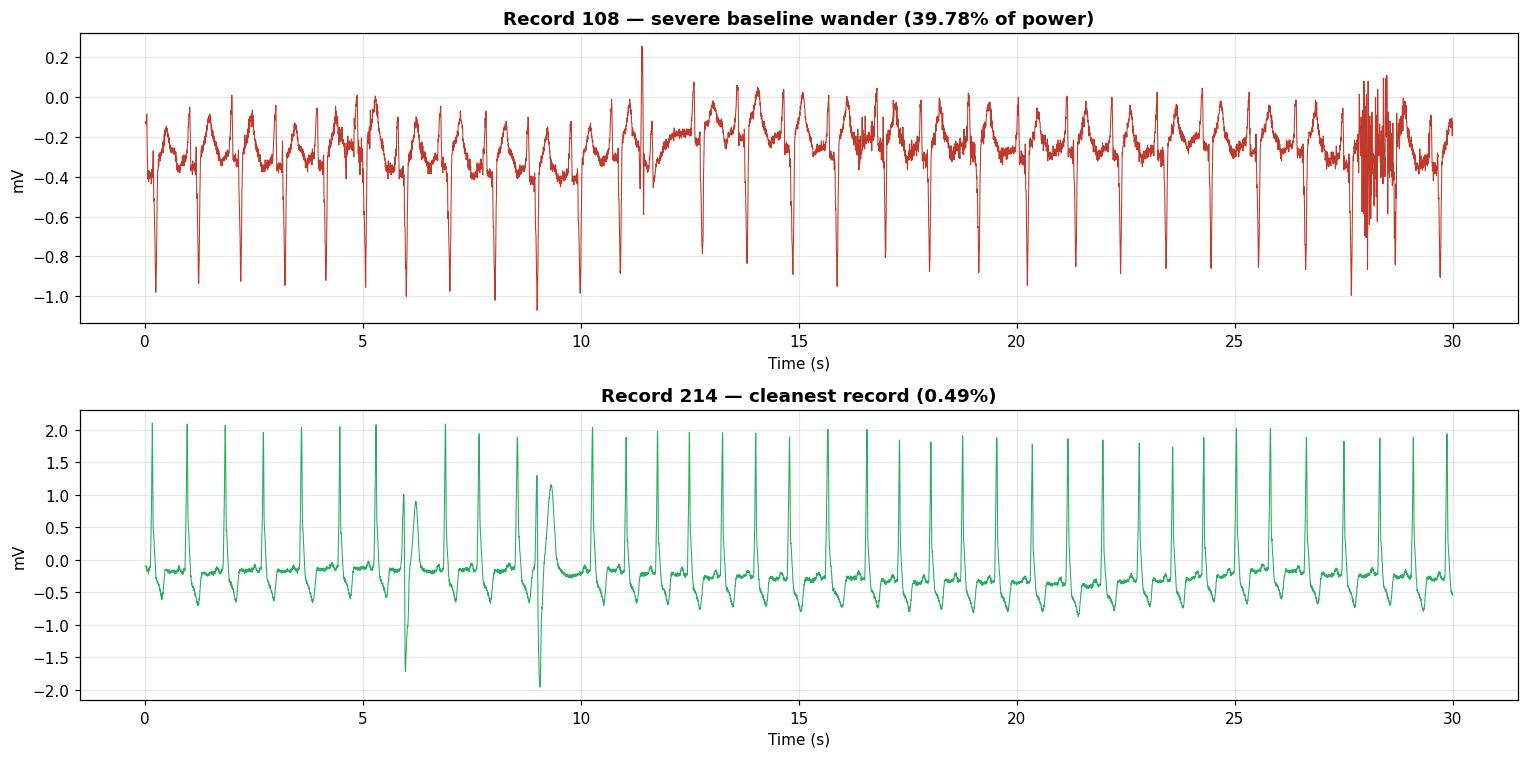

In [13]:
# Record 108 = worst baseline wander (39.78%) -> great demo case
# Record 214 = cleanest (0.49% baseline wander) -> contrast case
WORST_BW = '108'
CLEANEST = '214'

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, rec_name, title in [(axes[0], WORST_BW, f'Record {WORST_BW} — severe baseline wander (39.78% of power)'),
                              (axes[1], CLEANEST, f'Record {CLEANEST} — cleanest record (0.49%)')]:
    rec = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    x = rec.p_signal[:int(rec.fs*30), 0]
    t = np.arange(len(x)) / rec.fs
    ax.plot(t, x, linewidth=0.7, color='#c0392b' if rec_name==WORST_BW else '#27ae60')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('mV'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

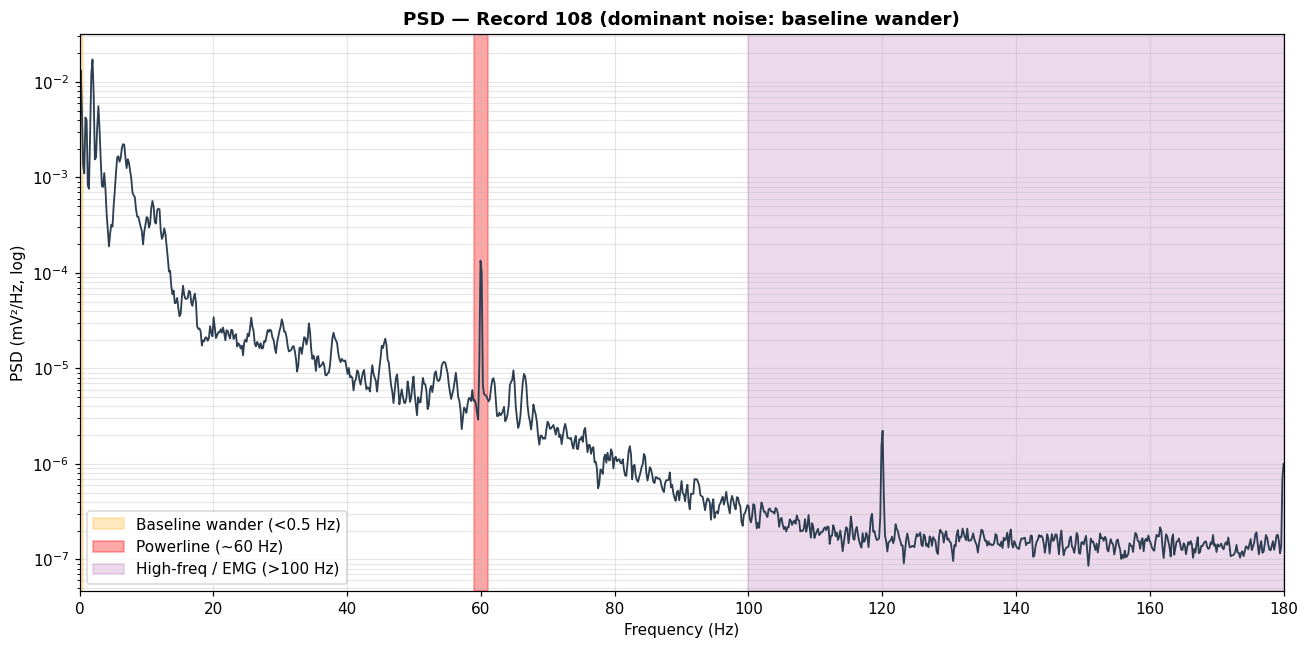

In [14]:
# Full working signal + PSD for record 108
RECORD = WORST_BW
rec = wfdb.rdrecord(os.path.join(DATA_DIR, RECORD))
FS = rec.fs
raw = rec.p_signal[:FS*120, 0]   # first 2 minutes
t = np.arange(len(raw)) / FS

freqs, psd = signal.welch(raw, fs=FS, nperseg=2048)
fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(freqs, psd, color='#2c3e50', linewidth=1.2)
ax.axvspan(0, 0.5, color='orange', alpha=0.25, label='Baseline wander (<0.5 Hz)')
ax.axvspan(59, 61, color='red', alpha=0.35, label='Powerline (~60 Hz)')
ax.axvspan(100, FS/2, color='purple', alpha=0.15, label='High-freq / EMG (>100 Hz)')
ax.set_xlim(0, 180)
ax.set_title(f'PSD — Record {RECORD} (dominant noise: baseline wander)', fontweight='bold')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (mV²/Hz, log)')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

In [19]:
from scipy.signal import butter, filtfilt, iirnotch, kaiserord, firwin

FS = 360

def highpass(x, cutoff=0.5, fs=FS, order=4):
    b, a = butter(order, cutoff/(fs/2), btype='high')
    return filtfilt(b, a, x)

def lowpass(x, cutoff=35, fs=FS, order=4):
    b, a = butter(order, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, x)

def bandpass(x, low=0.5, high=35, fs=FS, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, x)

def notch60(x, f0=60, Q=30, fs=FS):
    b, a = iirnotch(f0/(fs/2), Q)
    return filtfilt(b, a, x)

def fir_bandstop_kaiser(x, f0=60, notch_width=4, ripple_db=60, trans_width=2, fs=FS):
    nyq = fs/2
    N, beta = kaiserord(ripple_db, trans_width/nyq)
    if N % 2 == 0: N += 1
    taps = firwin(N, [(f0-notch_width/2)/nyq, (f0+notch_width/2)/nyq],
                  window=('kaiser', beta), pass_zero='bandstop')
    return filtfilt(taps, [1.0], x)

In [20]:
def plot_fft(x, fs, title, ax):
    n = len(x)
    freqs = np.fft.rfftfreq(n, 1/fs)
    mag = np.abs(np.fft.rfft(x)) / n
    ax.plot(freqs, mag, linewidth=0.8)
    ax.set_xlim(0, 100)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Hz'); ax.set_ylabel('|X(f)|')
    ax.axvline(60, color='r', linestyle='--', alpha=0.5, label='60Hz')
    ax.legend()

In [21]:
rec = wfdb.rdrecord(os.path.join(DATA_DIR, WORST_BW))
x = rec.p_signal[:, 0]
fs = rec.fs

variants = {
    'raw':             x,
    'highpass_only':   highpass(x),
    'bandpass_only':   bandpass(x),
    'bandpass+notch':  notch60(bandpass(x)),
    'bandpass+fir_kaiser': fir_bandstop_kaiser(bandpass(x)),
}

print(f"{'Variant':<20}{'BaselineWander%':>16}{'Powerline%':>12}{'HighFreq%':>12}")
for name, sig in variants.items():
    bw = band_power_fraction(sig, 0, 0.5, fs)
    pl = band_power_fraction(sig, 59, 61, fs)
    hf = band_power_fraction(sig, 100, fs/2, fs)
    print(f"{name:<20}{bw:>16.3f}{pl:>12.4f}{hf:>12.4f}")

Variant              BaselineWander%  Powerline%   HighFreq%
raw                           39.776      0.0879      0.0235
highpass_only                  0.220      0.1777      0.0474
bandpass_only                  0.219      0.0000      0.0000
bandpass+notch                 0.219      0.0000      0.0000
bandpass+fir_kaiser            0.219      0.0000      0.0000


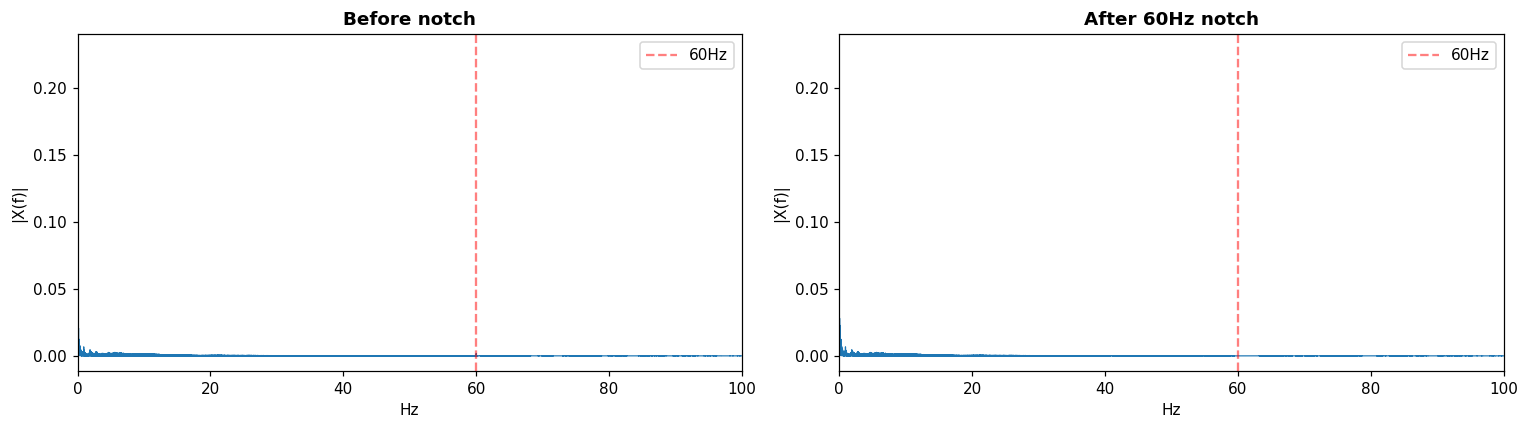

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_fft(x, fs, 'Before notch', axes[0])
plot_fft(notch60(x), fs, 'After 60Hz notch', axes[1])
plt.tight_layout(); plt.show()

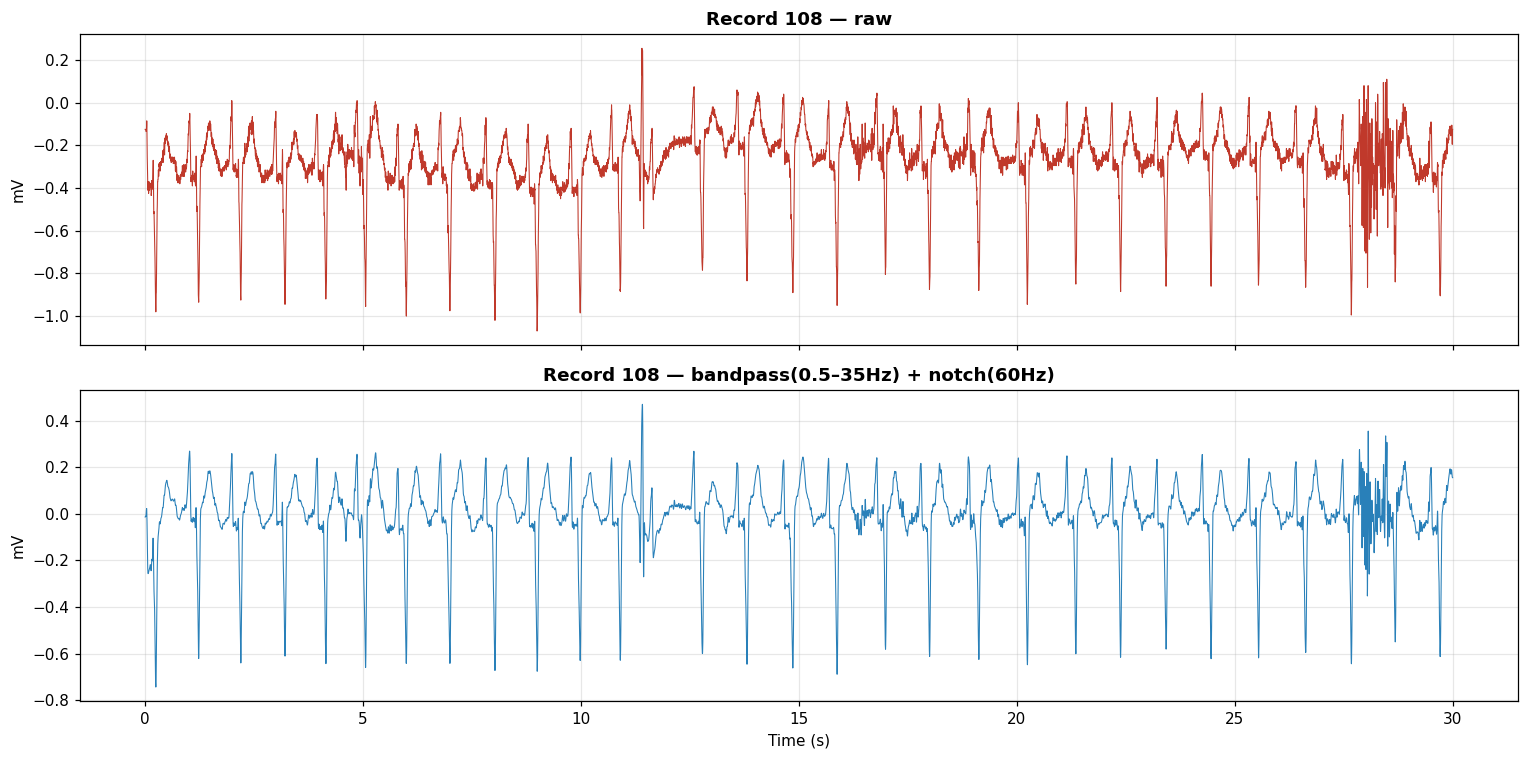

In [24]:
best = variants['bandpass+notch']
t = np.arange(int(fs*30)) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(t, x[:int(fs*30)], linewidth=0.7, color='#c0392b')
axes[0].set_title(f'Record {WORST_BW} — raw', fontweight='bold')
axes[1].plot(t, best[:int(fs*30)], linewidth=0.7, color='#2980b9')
axes[1].set_title(f'Record {WORST_BW} — bandpass(0.5–35Hz) + notch(60Hz)', fontweight='bold')
for ax in axes:
    ax.set_ylabel('mV'); ax.grid(alpha=0.3)
axes[1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

In [49]:
def swt_denoise(x, wavelet='rbio3.9', level=5, threshold_scale=0.5):
    n = len(x)
    pad = (2**level - n % 2**level) % 2**level
    x_pad = np.pad(x, (0, pad), mode='reflect')
    coeffs = pywt.swt(x_pad, wavelet, level=level)
    denoised_coeffs = []
    for i, (cA, cD) in enumerate(coeffs):
        sigma = np.median(np.abs(cD)) / 0.6745
        thresh = threshold_scale * sigma * np.sqrt(2*np.log(len(cD)))
        cD_thresh = pywt.threshold(cD, thresh, mode='soft')
        if i == len(coeffs) - 1:          # آخر مستوى = الباسلاين
            cA = cA - np.median(cA)
        denoised_coeffs.append((cA, cD_thresh))
    rec = pywt.iswt(denoised_coeffs, wavelet)
    return rec[:n]

In [50]:
swt_sig = swt_denoise(x)

variants['swt_rbio3.9'] = swt_sig

print(f"{'Variant':<20}{'BaselineWander%':>16}{'Powerline%':>12}{'HighFreq%':>12}")
for name, sig in variants.items():
    bw = band_power_fraction(sig, 0, 0.5, fs)
    pl = band_power_fraction(sig, 59, 61, fs)
    hf = band_power_fraction(sig, 100, fs/2, fs)
    print(f"{name:<20}{bw:>16.3f}{pl:>12.4f}{hf:>12.4f}")

Variant              BaselineWander%  Powerline%   HighFreq%
raw                           39.776      0.0879      0.0235
highpass_only                  0.220      0.1777      0.0474
bandpass_only                  0.219      0.0000      0.0000
bandpass+notch                 0.219      0.0000      0.0000
bandpass+fir_kaiser            0.219      0.0000      0.0000
swt_rbio3.9                   45.175      0.0039      0.0010
dwt_rbio3.9                   43.802      0.0065      0.0045


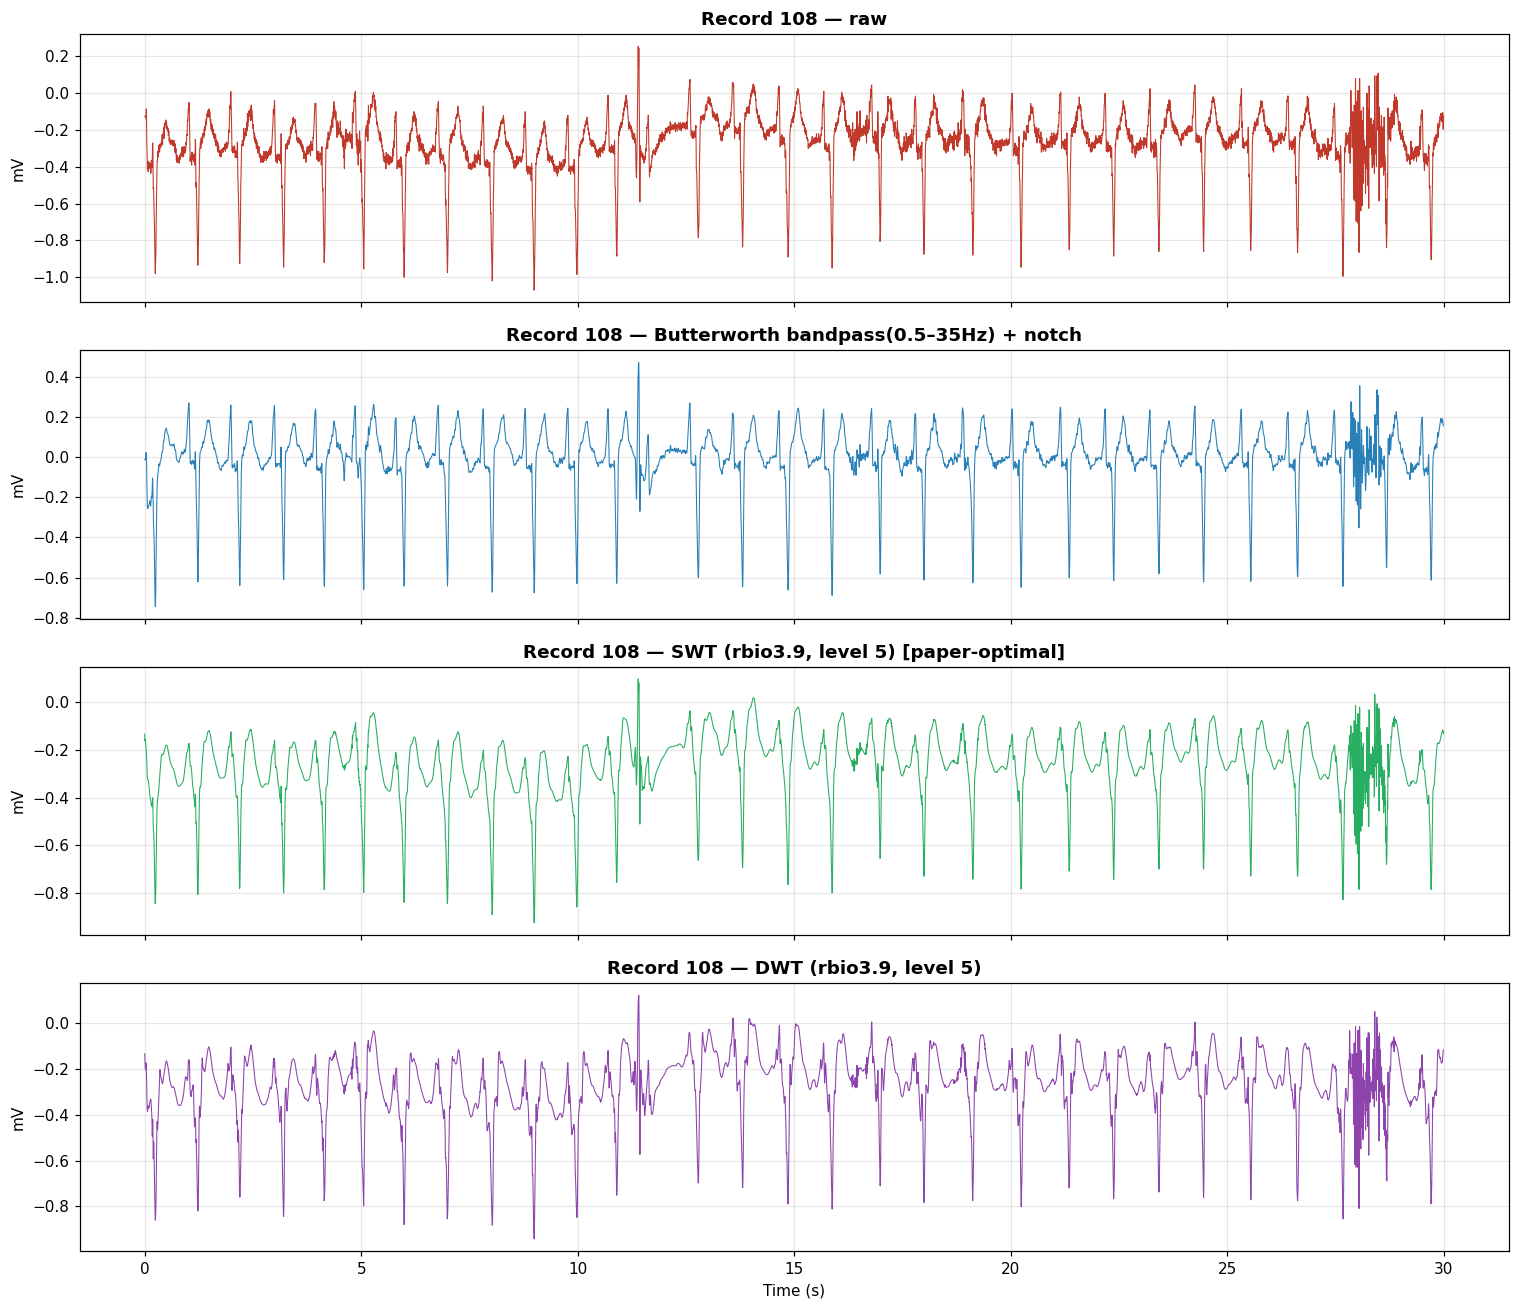

In [51]:
t = np.arange(int(fs*30)) / fs
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t, x[:int(fs*30)], linewidth=0.7, color='#c0392b')
axes[0].set_title('Record 108 — raw', fontweight='bold')

axes[1].plot(t, variants['bandpass+notch'][:int(fs*30)], linewidth=0.7, color='#2980b9')
axes[1].set_title('Record 108 — Butterworth bandpass(0.5–35Hz) + notch', fontweight='bold')

axes[2].plot(t, swt_sig[:int(fs*30)], linewidth=0.7, color='#27ae60')
axes[2].set_title('Record 108 — SWT (rbio3.9, level 5) [paper-optimal]', fontweight='bold')

axes[3].plot(t, dwt_sig[:int(fs*30)], linewidth=0.7, color='#8e44ad')
axes[3].set_title('Record 108 — DWT (rbio3.9, level 5)', fontweight='bold')

for ax in axes:
    ax.set_ylabel('mV'); ax.grid(alpha=0.3)
axes[3].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

In [52]:
def dwt_denoise(x, wavelet='rbio3.9', level=5, threshold_scale=0.5):
    coeffs = pywt.wavedec(x, wavelet, level=level)
    cA = coeffs[0] - np.median(coeffs[0])
    denoised = [cA]
    for cD in coeffs[1:]:
        sigma = np.median(np.abs(cD)) / 0.6745
        thresh = threshold_scale * sigma * np.sqrt(2*np.log(len(cD)))
        denoised.append(pywt.threshold(cD, thresh, mode='soft'))
    rec = pywt.waverec(denoised, wavelet)
    return rec[:len(x)]

In [54]:
def snr_improvement(raw, filtered):
    noise = raw - filtered
    signal_power = np.sum(filtered**2)
    noise_power = np.sum(noise**2)
    return 10*np.log10(signal_power/noise_power) if noise_power > 0 else np.inf

In [55]:
def preprocess_record(rec_name, data_dir=DATA_DIR):
    rec = wfdb.rdrecord(os.path.join(data_dir, rec_name))
    x = rec.p_signal[:, 0]
    return swt_denoise(x), rec.fs

cleaned = {}
for rec_name in records:
    sig, fs = preprocess_record(rec_name)
    cleaned[rec_name] = sig
print(f"Preprocessed {len(cleaned)} records")

Preprocessed 48 records


In [53]:
for name in ['bandpass+notch', 'swt_rbio3.9', 'dwt_rbio3.9']:
    snr = snr_improvement(x, variants[name])
    corr = np.corrcoef(x, variants[name])[0,1]
    print(f"{name:<20} SNR={snr:6.2f} dB   corr-with-raw={corr:.4f}")

bandpass+notch       SNR= -5.68 dB   corr-with-raw=0.5927
swt_rbio3.9          SNR= 18.55 dB   corr-with-raw=0.9900
dwt_rbio3.9          SNR= 17.20 dB   corr-with-raw=0.9856


In [35]:
print(f"{'Record':<8}{'Technique':<20}{'SNR(dB)':>10}{'Corr':>8}")
for rec_name in ['108', '121', '111', '222']:
    rec = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    xr = rec.p_signal[:, 0]
    v = {
        'bandpass+notch': notch60(bandpass(xr)),
        'swt_rbio3.9': swt_denoise(xr),
        'dwt_rbio3.9': dwt_denoise(xr),
    }
    for name, sig in v.items():
        snr = snr_improvement(xr, sig)
        corr = np.corrcoef(xr, sig)[0,1]
        print(f"{rec_name:<8}{name:<20}{snr:>10.2f}{corr:>8.4f}")

Record  Technique              SNR(dB)    Corr
108     bandpass+notch           -5.68  0.5927
108     swt_rbio3.9              18.55  0.9900
108     dwt_rbio3.9              17.20  0.9856
121     bandpass+notch          -13.63  0.5926
121     swt_rbio3.9              28.79  0.9948
121     dwt_rbio3.9              26.77  0.9914
111     bandpass+notch           -1.94  0.7479
111     swt_rbio3.9              13.49  0.9728
111     dwt_rbio3.9              11.98  0.9580
222     bandpass+notch           -3.87  0.7510
222     swt_rbio3.9              14.58  0.9739
222     dwt_rbio3.9              13.51  0.9642


In [56]:
def preprocess_record(rec_name, data_dir=DATA_DIR):
    rec = wfdb.rdrecord(os.path.join(data_dir, rec_name))
    x = rec.p_signal[:, 0]
    return swt_denoise(x), rec.fs

cleaned = {}
for rec_name in records:
    sig, fs = preprocess_record(rec_name)
    cleaned[rec_name] = sig
print(f"Preprocessed {len(cleaned)} records")

Preprocessed 48 records


In [59]:
from wfdb import processing

def detect_rpeaks(sig, fs):
    xqrs = processing.XQRS(sig=sig, fs=fs)
    xqrs.detect(verbose=False)
    return xqrs.qrs_inds

sig = cleaned['108']
fs_108 = wfdb.rdrecord(os.path.join(DATA_DIR, '108')).fs
detected = detect_rpeaks(sig, fs_108)
r_peaks = detected
print(f"Detected {len(detected)} R-peaks in record 108")

Detected 1767 R-peaks in record 108


In [38]:
def evaluate_detection(rec_name, cleaned_sig, fs, tol_ms=100):
    ann = wfdb.rdann(os.path.join(DATA_DIR, rec_name), 'atr')
    true_peaks = ann.sample[np.isin(ann.symbol, list('NLRBAaJSVrFejnE/fQ?'))]  # beat annotations only
    detected = detect_rpeaks(cleaned_sig, fs)

    tol = int(tol_ms/1000 * fs)
    matched = 0
    used = np.zeros(len(detected), dtype=bool)
    for tp in true_peaks:
        diffs = np.abs(detected - tp)
        idx = np.argmin(diffs)
        if diffs[idx] <= tol and not used[idx]:
            matched += 1
            used[idx] = True

    sensitivity = matched / len(true_peaks) if len(true_peaks) else 0
    precision = matched / len(detected) if len(detected) else 0
    return len(true_peaks), len(detected), matched, sensitivity, precision

print(f"{'Record':<8}{'True':>6}{'Detected':>10}{'Matched':>9}{'Sens':>8}{'Prec':>8}")
for rec_name in ['108', '121', '111', '222', '100']:
    fs_r = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name)).fs
    n_true, n_det, n_match, sens, prec = evaluate_detection(rec_name, cleaned[rec_name], fs_r)
    print(f"{rec_name:<8}{n_true:>6}{n_det:>10}{n_match:>9}{sens:>8.3f}{prec:>8.3f}")

Record    True  Detected  Matched    Sens    Prec
108       1763      1767     1733   0.983   0.981
121       1863      1862     1861   0.999   0.999
111       2124      2122     2122   0.999   1.000
222       2483      2470     2469   0.994   1.000
100       2273      2273     2273   1.000   1.000


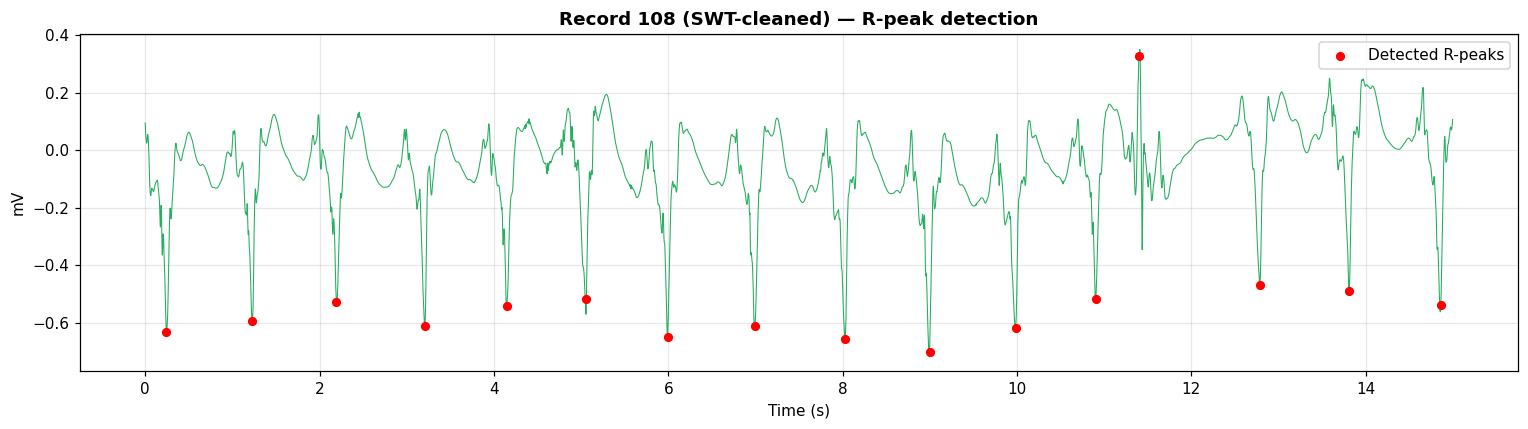

In [61]:
fig, ax = plt.subplots(figsize=(14, 4))
window = int(fs_108*15)
ax.plot(np.arange(window)/fs_108, sig[:window], linewidth=0.7, color='#27ae60')
peaks_in_window = detected[detected < window]
ax.scatter(peaks_in_window/fs_108, sig[peaks_in_window], color='red', s=25, zorder=5, label='Detected R-peaks')
ax.set_title('Record 108 (SWT-cleaned) — R-peak detection', fontweight='bold')
ax.set_xlabel('Time (s)'); ax.set_ylabel('mV'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# segment extraction around each R-peak

In [67]:
def extract_morphology(sig, r_peaks, fs):
    windows = {
        'P_wave':    (-0.20, -0.10),
        'QRS':       (-0.05,  0.05),
        'ST_segment':( 0.06,  0.12),
        'T_wave':    ( 0.15,  0.35),
    }
    results = {k: [] for k in windows}
    r_amp = []

    for r in r_peaks:
        if r - int(0.3*fs) < 0 or r + int(0.4*fs) >= len(sig):
            continue
        # R-amplitude = الفرق بين قمة R وأقرب نقطة تحتها (نفس منطق peak-to-peak)
        local = sig[r - int(0.05*fs): r + int(0.05*fs)]
        r_amp.append(np.max(local) - np.min(local))

        for name, (start, end) in windows.items():
            i0 = r + int(start*fs)
            i1 = r + int(end*fs)
            seg = sig[i0:i1]
            if name in ('QRS',):
                results[name].append(np.ptp(seg))
            else:
                results[name].append(np.max(seg) - np.min(seg))

    summary = {k: (np.mean(v), np.std(v)) for k, v in results.items()}
    summary['R_amplitude'] = (np.mean(r_amp), np.std(r_amp))
    return summary

# compare raw vs each filtered variant on record 108 

In [68]:
rec = wfdb.rdrecord(os.path.join(DATA_DIR, '108'))
x_raw = rec.p_signal[:, 0]
fs = rec.fs
r_peaks = detect_rpeaks(cleaned['108'], fs)  # already SWT-cleaned, keep this

morph_variants = {
    'raw': x_raw,
    'bandpass+notch': notch60(bandpass(x_raw)),
    'swt_rbio3.9': cleaned['108'],       
    'dwt_rbio3.9': dwt_denoise(x_raw),
}

print(f"{'Technique':<18}{'P-wave':>9}{'QRS':>9}{'ST-seg':>9}{'T-wave':>9}{'R-amp':>9}")
morph_results = {}
for name, sig in morph_variants.items():
    m = extract_morphology(sig, r_peaks, fs)
    morph_results[name] = m
    print(f"{name:<18}{m['P_wave'][0]:>9.4f}{m['QRS'][0]:>9.4f}{m['ST_segment'][0]:>9.4f}{m['T_wave'][0]:>9.4f}{m['R_amplitude'][0]:>9.4f}")

Technique            P-wave      QRS   ST-seg   T-wave    R-amp
raw                  0.2020   1.0837   0.0929   0.2497   1.0837
bandpass+notch       0.1740   1.0463   0.0569   0.2080   1.0463
swt_rbio3.9          0.1272   0.8411   0.0782   0.1764   0.8411
dwt_rbio3.9          0.1886   0.8824   0.1357   0.1908   0.8824


# % preserved relative to raw 

In [70]:
print(f"{'Technique':<18}{'P-wave%':>10}{'QRS%':>9}{'ST-seg%':>10}{'T-wave%':>10}{'R-amp%':>9}")
raw_m = morph_results['raw']
for name in ['bandpass+notch', 'swt_rbio3.9', 'dwt_rbio3.9']:
    m = morph_results[name]
    pct = {k: 100 * m[k][0] / raw_m[k][0] if raw_m[k][0] != 0 else 0 for k in raw_m}
    print(f"{name:<18}{pct['P_wave']:>10.1f}{pct['QRS']:>9.1f}{pct['ST_segment']:>10.1f}{pct['T_wave']:>10.1f}{pct['R_amplitude']:>9.1f}")

Technique            P-wave%     QRS%   ST-seg%   T-wave%   R-amp%
bandpass+notch          86.1     96.6      61.3      83.3     96.6
swt_rbio3.9             63.0     77.6      84.2      70.6     77.6
dwt_rbio3.9             93.4     81.4     146.1      76.4     81.4


# visual single-beat overlay 

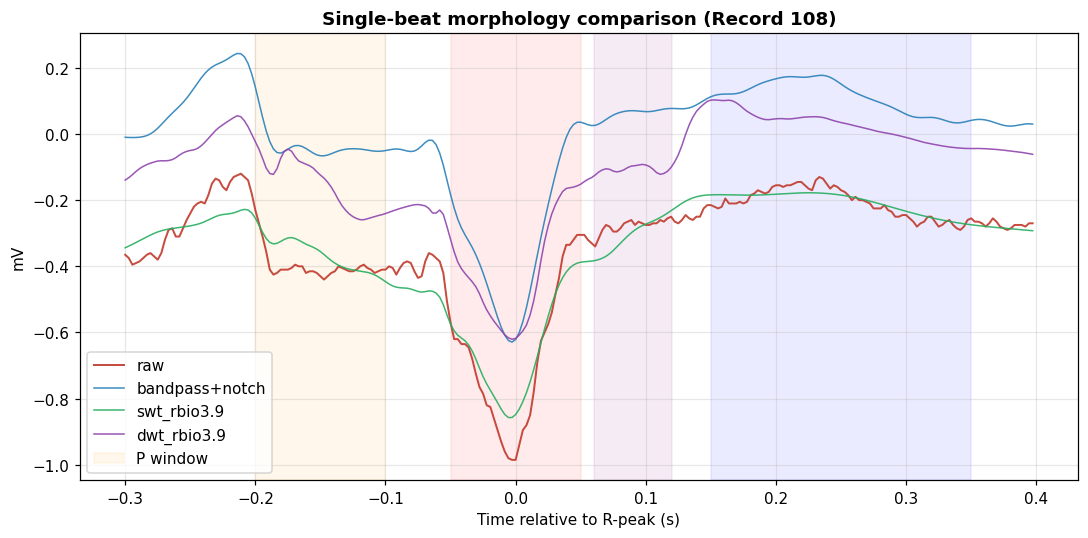

In [66]:
rec = wfdb.rdrecord(os.path.join(DATA_DIR, '108'))
x_raw = rec.p_signal[:, 0]
fs = rec.fs

morph_variants = {
    'raw': x_raw,
    'bandpass+notch': notch60(bandpass(x_raw)),
    'swt_rbio3.9': cleaned['108'],
    'dwt_rbio3.9': dwt_denoise(x_raw),
}

r = r_peaks[10]
i0, i1 = r - int(0.3*fs), r + int(0.4*fs)
t_beat = np.arange(i1-i0)/fs - 0.3

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'raw': '#c0392b', 'bandpass+notch': '#2980b9', 'swt_rbio3.9': '#27ae60', 'dwt_rbio3.9': '#8e44ad'}
for name, sig in morph_variants.items():
    ax.plot(t_beat, sig[i0:i1], label=name, color=colors[name], linewidth=1.3 if name=='raw' else 1.0, alpha=0.9)

ax.axvspan(-0.20, -0.10, alpha=0.08, color='orange', label='P window')
ax.axvspan(-0.05, 0.05, alpha=0.08, color='red')
ax.axvspan(0.06, 0.12, alpha=0.08, color='purple')
ax.axvspan(0.15, 0.35, alpha=0.08, color='blue')
ax.set_title('Single-beat morphology comparison (Record 108)', fontweight='bold')
ax.set_xlabel('Time relative to R-peak (s)'); ax.set_ylabel('mV')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()